# F1 Pit Stop Prediction — EDA + Performance-Optimized Modeling

**Objective:** deeply explore the train/test data, identify the strongest signals and distribution shifts, document the findings, and use those findings to build a faster and stronger LightGBM pipeline.

### What is included
- Dataset quality and structure checks
- Target imbalance analysis
- Numerical distributions and outlier views
- Train vs test distribution-shift analysis
- Target rate analysis by tyre compound, pit-stop count, stint, year, position, driver and race
- Correlation analysis
- Missing-value / duplicate checks
- Feature engineering motivated by the EDA
- Leakage-aware validation discussion
- Fast LightGBM model with early stopping
- Optional multi-seed ensemble
- Submission generation from `sample_submission.csv`

> **Important:** this version intentionally uses **only train.csv, test.csv and sample_submission.csv**. No external F1 dataset is required.

In [1]:
# Imports and reproducibility
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

# Kaggle paths first; local /mnt/data fallback for development.
TRAIN_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train.csv"
TEST_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\test.csv"
SAMPLE_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv"

if not os.path.exists(TRAIN_PATH): TRAIN_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train.csv"
if not os.path.exists(TEST_PATH): TEST_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\test.csv"
if not os.path.exists(SAMPLE_PATH): SAMPLE_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv"

print("Train:", TRAIN_PATH)
print("Test:", TEST_PATH)
print("Sample:", SAMPLE_PATH)

Train: D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train.csv
Test: D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\test.csv
Sample: D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv


In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

TARGET = "PitNextLap"
ID_COL = "id"

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Submission shape: {sample_submission.shape}")
print("\nTrain columns:")
print(train.columns.tolist())

assert TARGET in train.columns
assert TARGET not in test.columns
assert len(test) == len(sample_submission)
assert test[ID_COL].equals(sample_submission[ID_COL])


Train shape: (439140, 16)
Test shape:  (188165, 15)
Submission shape: (188165, 2)

Train columns:
['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


## 1. Data quality and structure

The first goal is to make sure there are no hidden data-quality issues before modeling.

In [3]:
quality = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "missing_pct": train.isna().mean().mul(100).round(3),
    "nunique": train.nunique(),
})
quality.sort_values(["missing", "nunique"], ascending=[False, True])

,dtype,missing,missing_pct,nunique
PitStop,int64,0,0.0,2
PitNextLap,float64,0,0.0,2
Year,int64,0,0.0,4
Compound,object,0,0.0,5
Stint,int64,0,0.0,8
Position,int64,0,0.0,20
Race,object,0,0.0,26
Position_Change,float64,0,0.0,37
LapNumber,int64,0,0.0,78
TyreLife,float64,0,0.0,78


In [4]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate IDs in train:", train[ID_COL].duplicated().sum())
print("Duplicate IDs in test:", test[ID_COL].duplicated().sum())
print("Train/test ID overlap:", len(set(train[ID_COL]) & set(test[ID_COL])))

print("\nTarget distribution:")
target_counts = train[TARGET].value_counts().sort_index()
target_pct = train[TARGET].value_counts(normalize=True).sort_index().mul(100)
print(pd.DataFrame({"count": target_counts, "pct": target_pct.round(2)}))

Duplicate rows in train: 0
Duplicate IDs in train: 0
Duplicate IDs in test: 0
Train/test ID overlap: 0

Target distribution:
             count   pct
PitNextLap              
0.0         351759  80.1
1.0          87381  19.9


### Finding — target imbalance
The positive class is substantially smaller than the negative class. ROC-AUC is therefore appropriate, but accuracy would be misleading. The modeling section keeps the original class distribution and evaluates with ROC-AUC.

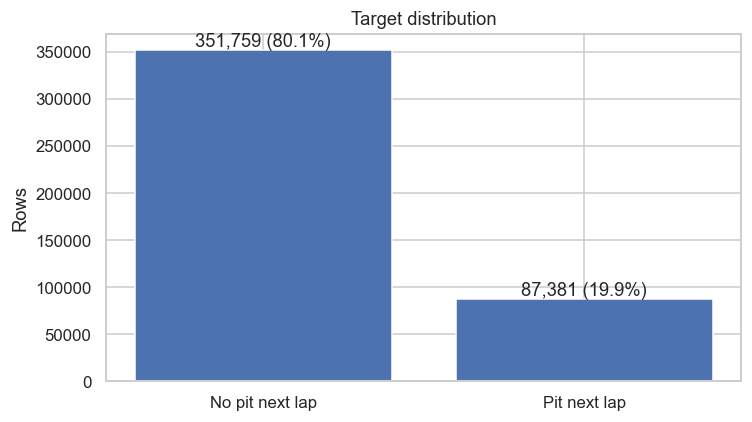

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = train[TARGET].value_counts().sort_index()
labels = ["No pit next lap", "Pit next lap"]
ax.bar(labels, counts.values)
ax.set_title("Target distribution")
ax.set_ylabel("Rows")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,} ({v/len(train):.1%})", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 2. Numerical feature EDA

In [6]:
numeric_features = [
    "LapNumber", "TyreLife", "LapTime (s)", "LapTime_Delta",
    "Cumulative_Degradation", "RaceProgress", "Position_Change"
]

train[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026
RaceProgress,439140.0,0.337661,0.253277,0.012821,0.12987,0.269231,0.513158,1.000
Position_Change,439140.0,0.101542,4.006765,-18.000000,-1.00000,0.000000,2.000000,18.000


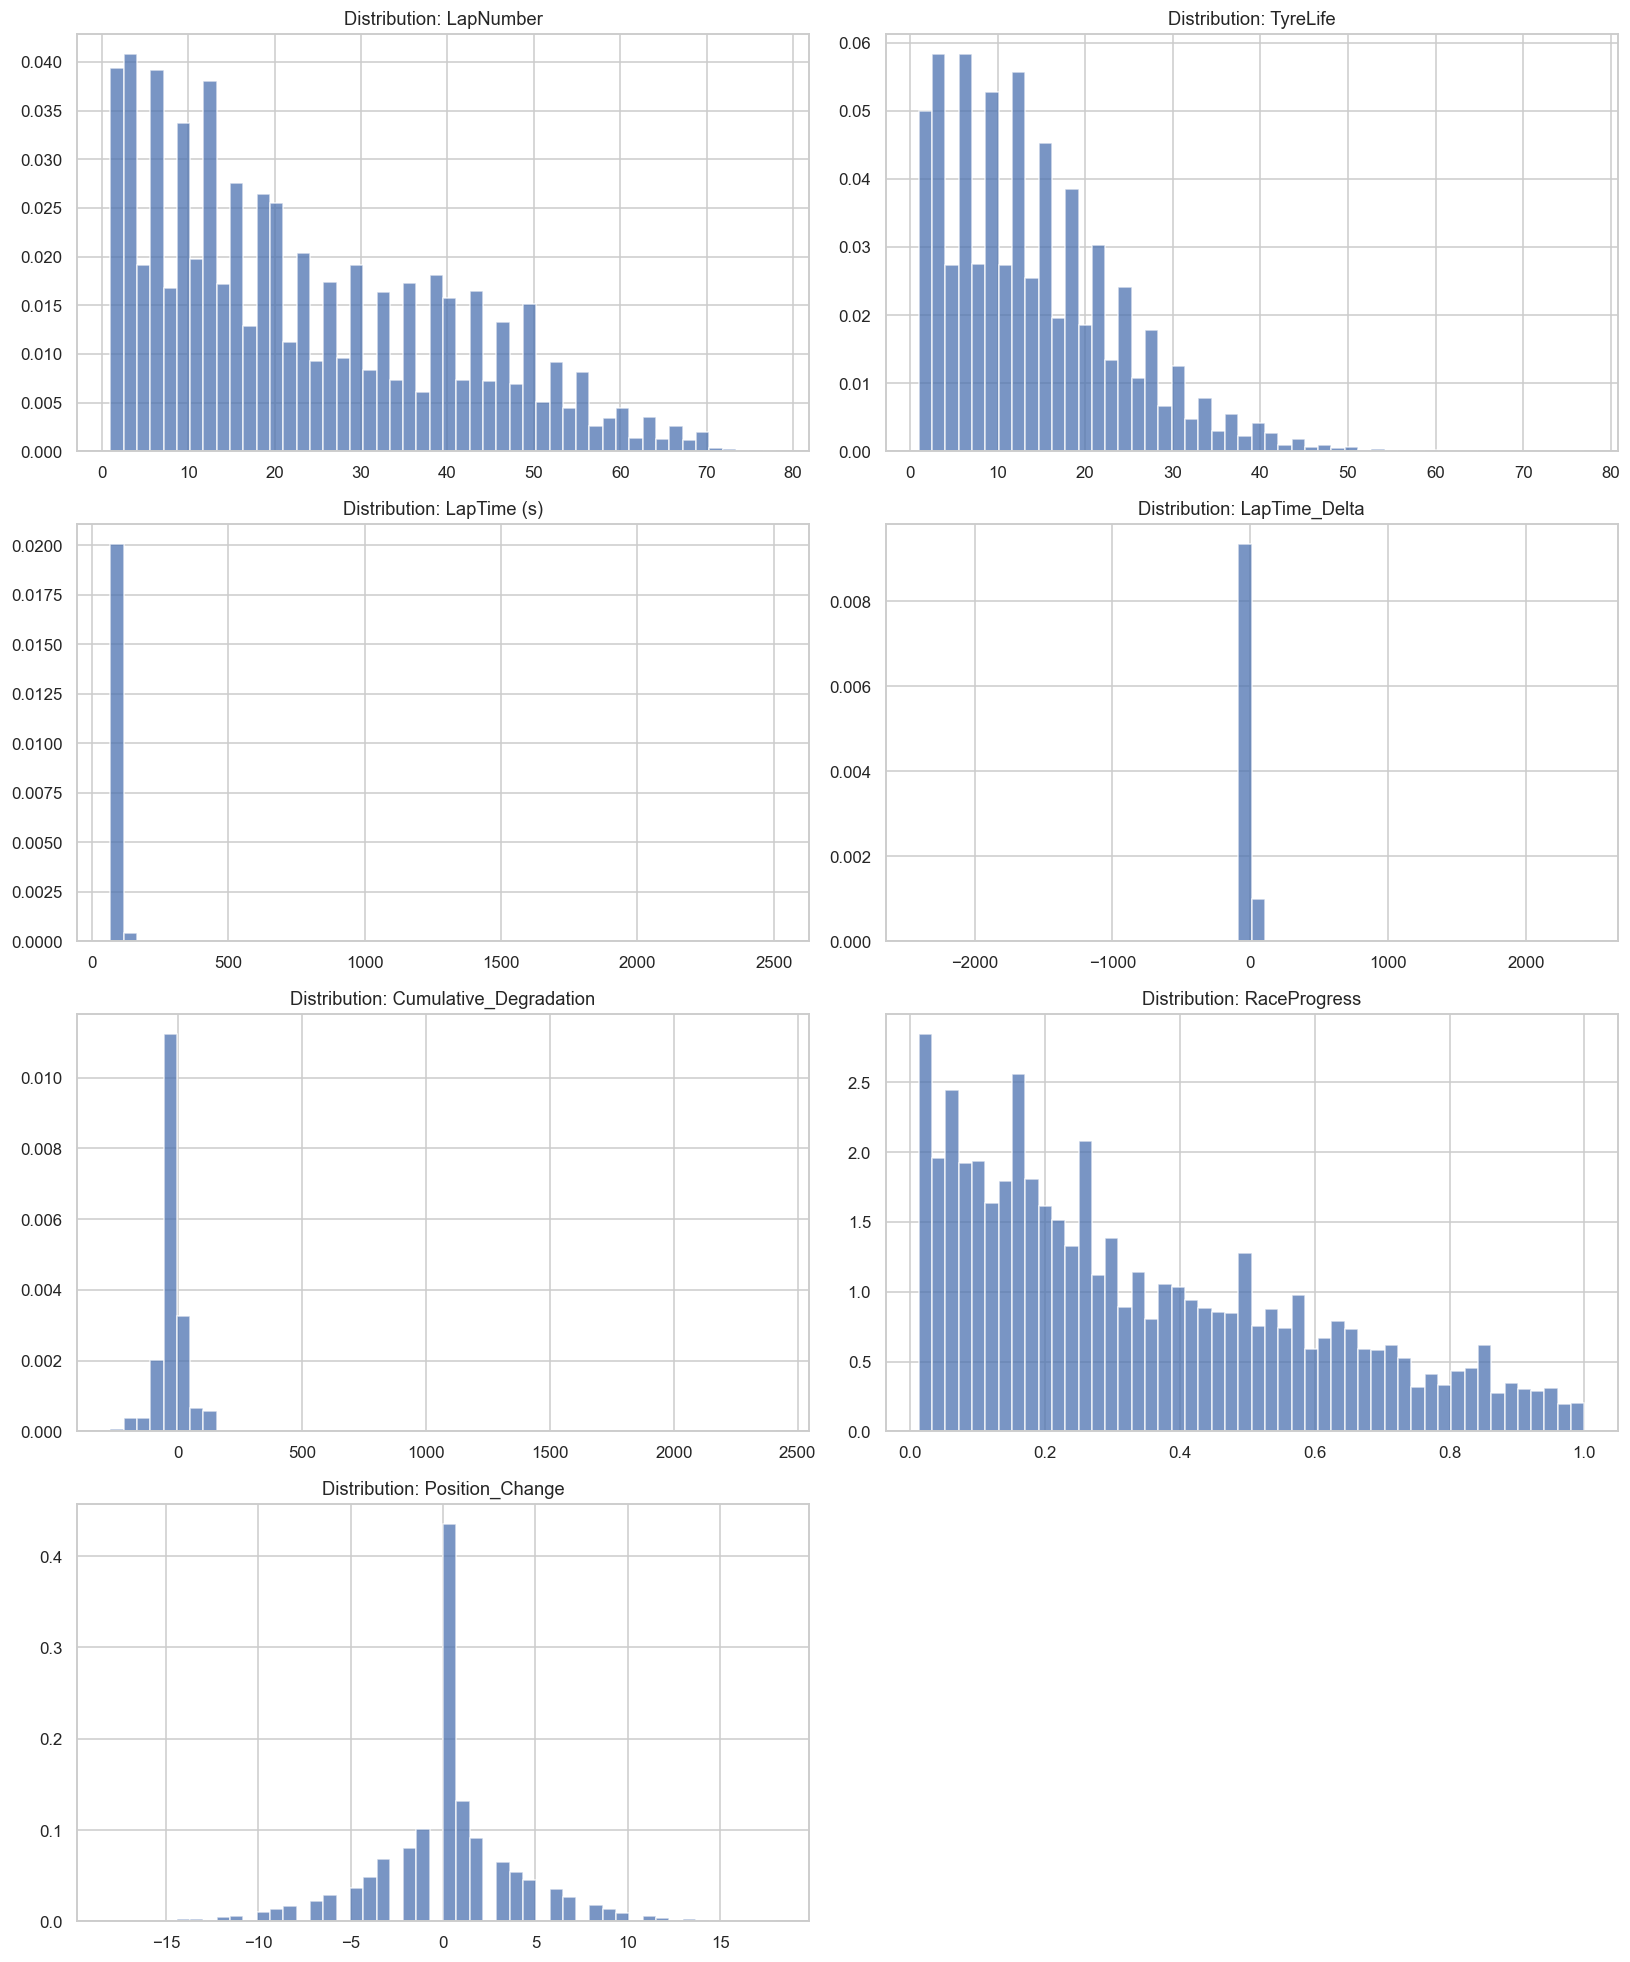

In [7]:
# Distribution overview
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].hist(train[col].dropna(), bins=50, density=True, alpha=0.75)
    axes[i].set_title(f"Distribution: {col}")
for j in range(len(numeric_features), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

## 3. Target rate by operational features

These plots answer a more useful modeling question than raw feature distributions: **how does the probability of a pit stop change across different race situations?**

In [8]:
def target_rate_table(df, col, min_count=100):
    out = df.groupby(col)[TARGET].agg(["mean", "sum", "count"]).reset_index()
    out["target_rate_pct"] = out["mean"] * 100
    return out[out["count"] >= min_count].sort_values("target_rate_pct", ascending=False)

for col in ["Compound", "PitStop", "Stint", "Year"]:
    display(target_rate_table(train, col, min_count=1).head(20))

,Compound,mean,sum,count,target_rate_pct
0,HARD,0.327537,55851.0,170518,32.753727
3,SOFT,0.193475,7496.0,38744,19.347512
1,INTERMEDIATE,0.152284,2647.0,17382,15.228397
2,MEDIUM,0.101131,21353.0,211141,10.113147
4,WET,0.025092,34.0,1355,2.509225


,PitStop,mean,sum,count,target_rate_pct
1,1,0.247829,14814.0,59775,24.782936
0,0,0.191285,72567.0,379365,19.128544


,Stint,mean,sum,count,target_rate_pct
1,2,0.391104,50662.0,129536,39.110363
2,3,0.293105,20294.0,69238,29.310494
3,4,0.171666,3245.0,18903,17.166587
0,1,0.059818,12938.0,216288,5.981839
4,5,0.053025,227.0,4281,5.302499
7,8,0.020000,1.0,50,2.000000
5,6,0.019231,14.0,728,1.923077
6,7,0.000000,0.0,116,0.000000


,Year,mean,sum,count,target_rate_pct
2,2024,0.295319,37538.0,127110,29.531902
3,2025,0.284389,26418.0,92894,28.438866
0,2022,0.266505,22117.0,82989,26.650520
1,2023,0.009607,1308.0,136147,0.960726


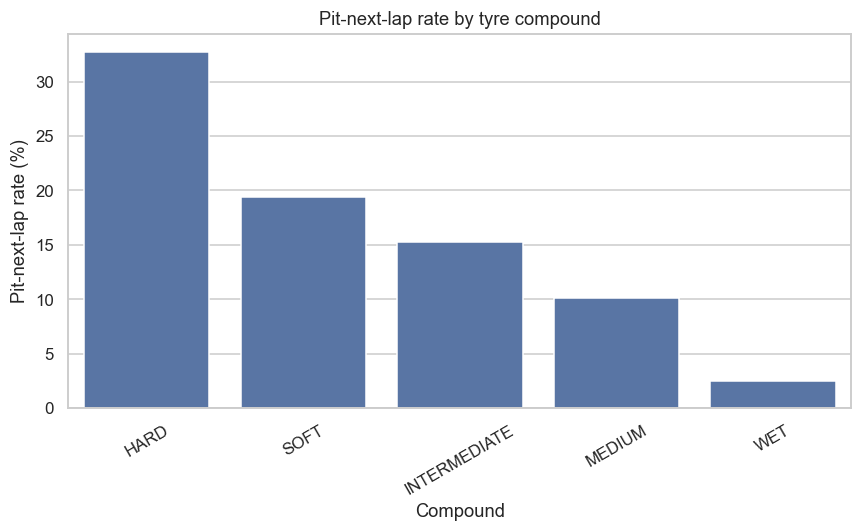

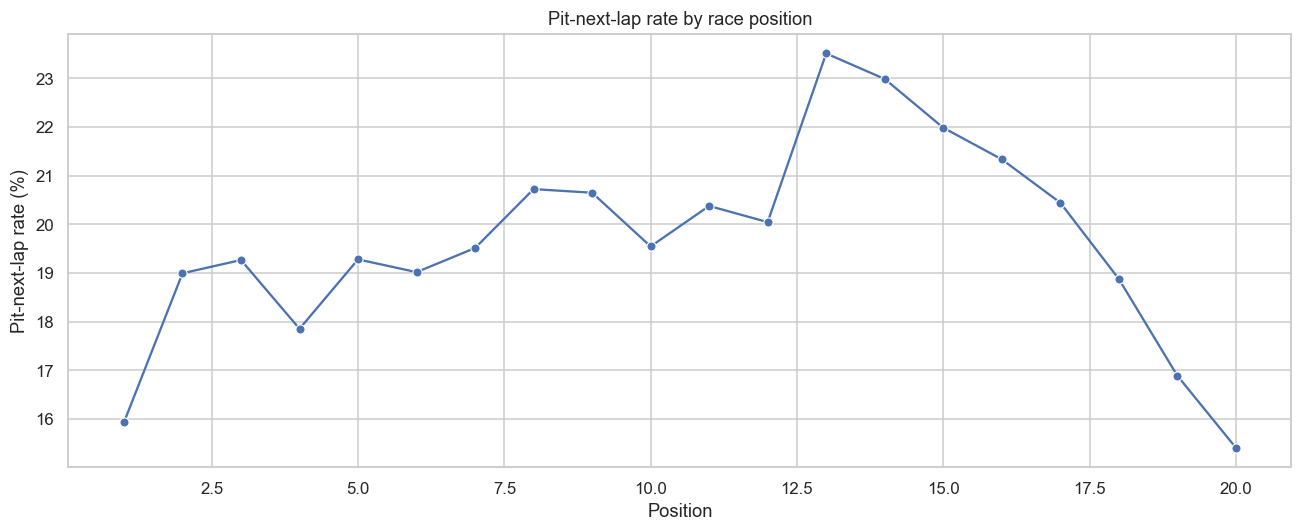

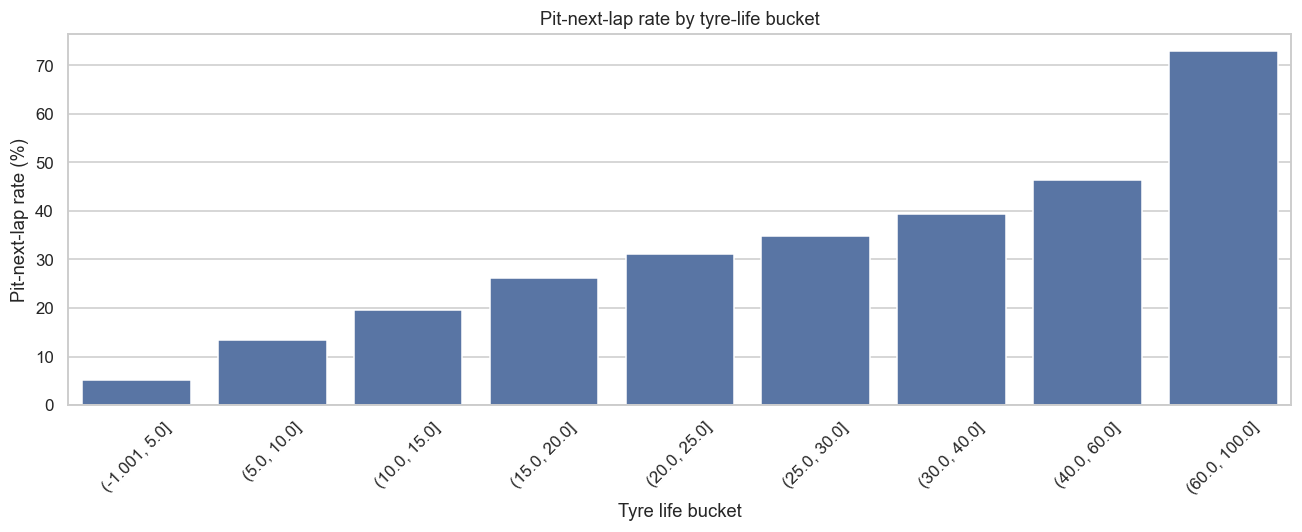

In [9]:
# Target rate by tyre compound
compound_rate = target_rate_table(train, "Compound", min_count=1)
plt.figure(figsize=(8, 5))
sns.barplot(data=compound_rate, x="Compound", y="target_rate_pct", color="C0")
plt.title("Pit-next-lap rate by tyre compound")
plt.xlabel("Compound")
plt.ylabel("Pit-next-lap rate (%)")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

# Target rate by position
position_rate = target_rate_table(train, "Position", min_count=200)
plt.figure(figsize=(12, 5))
sns.lineplot(data=position_rate.sort_values("Position"), x="Position", y="target_rate_pct", marker="o", color="C0")
plt.title("Pit-next-lap rate by race position")
plt.ylabel("Pit-next-lap rate (%)")
plt.tight_layout(); plt.show()

# Target rate by tyre life
life_bins = pd.cut(train["TyreLife"], bins=[-1, 5, 10, 15, 20, 25, 30, 40, 60, 100], include_lowest=True)
life_rate = train.groupby(life_bins, observed=False)[TARGET].mean().mul(100).reset_index(name="target_rate_pct")
plt.figure(figsize=(12, 5))
sns.barplot(data=life_rate, x="TyreLife", y="target_rate_pct", color="C0")
plt.title("Pit-next-lap rate by tyre-life bucket")
plt.ylabel("Pit-next-lap rate (%)")
plt.xlabel("Tyre life bucket")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

### Finding — tyre age and race state are expected to be important
The target-rate plots reveal whether pit decisions concentrate at particular tyre ages, compounds, positions and race stages. These patterns motivate features that describe **remaining race distance, tyre age relative to race length, and interactions between tyre/race state** rather than relying only on the raw columns.

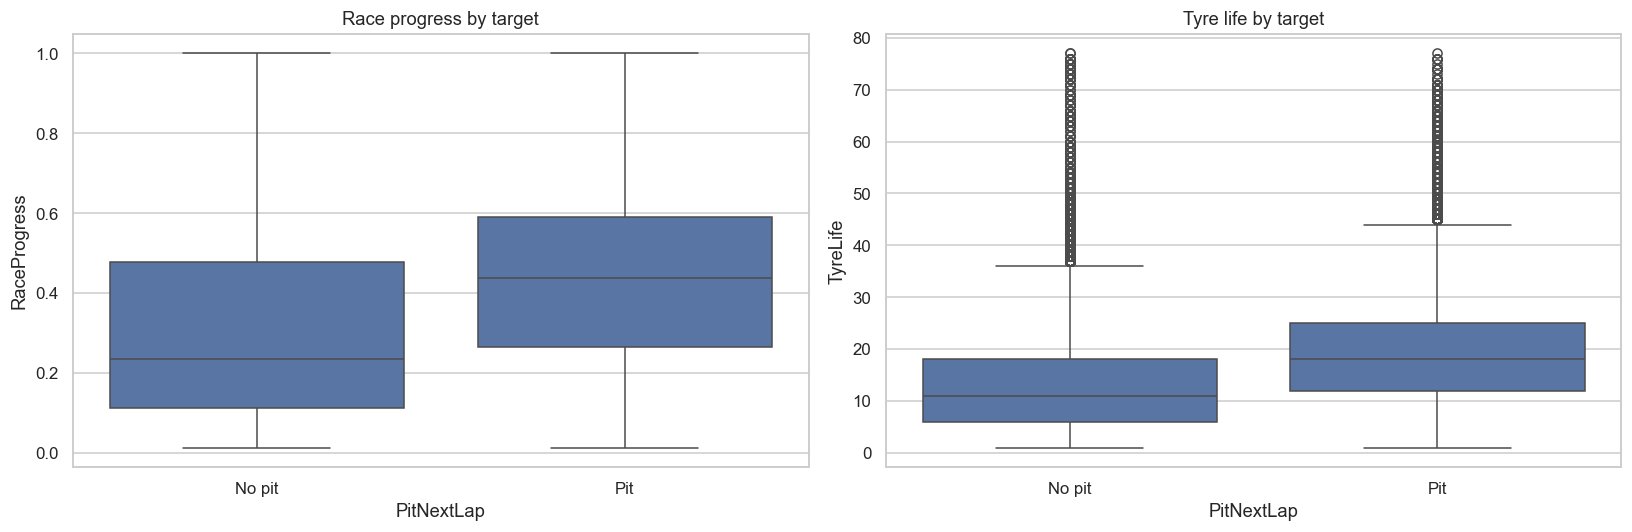

In [10]:
# Race progress and tyre life against the target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=train, x=TARGET, y="RaceProgress", ax=axes[0], color="C0")
axes[0].set_title("Race progress by target")
axes[0].set_xticklabels(["No pit", "Pit"])

sns.boxplot(data=train, x=TARGET, y="TyreLife", ax=axes[1], color="C0")
axes[1].set_title("Tyre life by target")
axes[1].set_xticklabels(["No pit", "Pit"])
plt.tight_layout(); plt.show()

## 4. Driver and race insights

Driver and race can be informative, but high-cardinality categories can also overfit. We inspect them before deciding how to use them.

In [11]:
driver_stats = train.groupby("Driver")[TARGET].agg(["mean", "count"]).reset_index()
race_stats = train.groupby("Race")[TARGET].agg(["mean", "count"]).reset_index()

print("Drivers:", train["Driver"].nunique())
print("Races:", train["Race"].nunique())
print("\nDrivers with highest pit-next-lap rate (min 500 rows):")
display(driver_stats[driver_stats["count"] >= 500].sort_values("mean", ascending=False).head(15))

print("Races with highest pit-next-lap rate (min 500 rows):")
display(race_stats[race_stats["count"] >= 500].sort_values("mean", ascending=False).head(15))

Drivers: 887
Races: 26

Drivers with highest pit-next-lap rate (min 500 rows):


,Driver,mean,count
865,STR,0.427451,1275
10,BEA,0.400000,555
3,ALO,0.393218,1386
875,VER,0.356469,1484
855,RUS,0.356066,1393
840,OCO,0.354975,1417
824,LEC,0.344544,1457
797,GAS,0.340072,1385
803,HAM,0.337261,1358
0,ALB,0.321694,1346


Races with highest pit-next-lap rate (min 500 rows):


,Race,mean,count
8,Chinese Grand Prix,0.388593,7311
18,Monaco Grand Prix,0.357398,21539
23,Spanish Grand Prix,0.319973,20483
4,Bahrain Grand Prix,0.287535,19535
5,Belgian Grand Prix,0.280382,9002
10,Emilia Romagna Grand Prix,0.272557,15483
11,French Grand Prix,0.257457,3185
24,São Paulo Grand Prix,0.253718,11497
12,Hungarian Grand Prix,0.239269,22481
21,Saudi Arabian Grand Prix,0.227431,18111


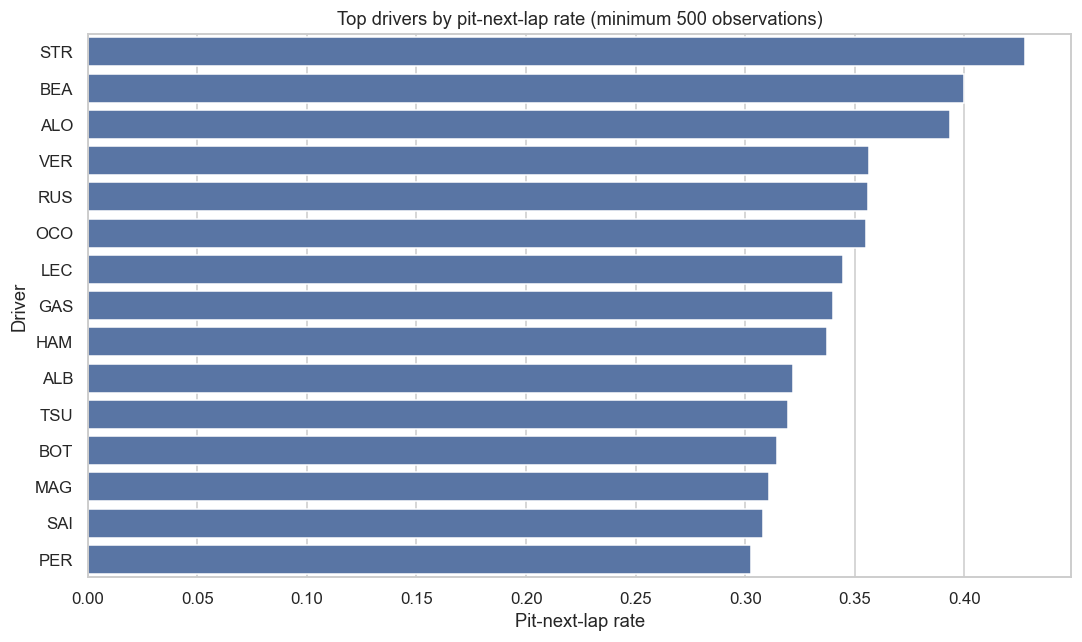

Driver categories in train: 887
Driver categories in test:  801
Test drivers unseen in train: 0


In [12]:
top_drivers = driver_stats[driver_stats["count"] >= 500].nlargest(15, "mean")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_drivers, x="mean", y="Driver", color="C0")
plt.title("Top drivers by pit-next-lap rate (minimum 500 observations)")
plt.xlabel("Pit-next-lap rate")
plt.tight_layout(); plt.show()

# Train/test driver overlap
train_drivers, test_drivers = set(train["Driver"]), set(test["Driver"])
print(f"Driver categories in train: {len(train_drivers)}")
print(f"Driver categories in test:  {len(test_drivers)}")
print(f"Test drivers unseen in train: {len(test_drivers - train_drivers)}")

### Finding — retain Driver, but control complexity
All/most test drivers being represented in training makes `Driver` potentially useful. Rather than dropping it as the original notebook did, the optimized model keeps it as a categorical feature. We avoid target encoding here because a careless encoding would leak validation information.

## 5. Train vs test distribution shift

A feature can look predictive in train but behave differently in test. We therefore compare numerical distributions and category proportions.

In [15]:
# !pip install jinja2

In [16]:
shift_rows = []
for col in numeric_features:
    a = train[col].dropna()
    b = test[col].dropna()
    stat, p = ks_2samp(a, b)
    shift_rows.append({
        "Feature": col,
        "Train mean": a.mean(),
        "Test mean": b.mean(),
        "Mean delta": b.mean() - a.mean(),
        "KS statistic": stat,
        "KS p-value": p,
    })
shift_df = pd.DataFrame(shift_rows).sort_values("KS statistic", ascending=False)
display(shift_df.style.format({"Train mean":"{:.4f}","Test mean":"{:.4f}","Mean delta":"{:.4f}","KS statistic":"{:.4f}","KS p-value":"{:.3g}"}))

,Feature,Train mean,Test mean,Mean delta,KS statistic,KS p-value
0,LapNumber,23.1059,23.0502,-0.0557,0.0032,0.125
5,RaceProgress,0.3377,0.3367,-0.0010,0.0031,0.156
1,TyreLife,14.1582,14.1606,0.0024,0.0029,0.217
3,LapTime_Delta,-3.7700,-3.5778,0.1922,0.0029,0.218
4,Cumulative_Degradation,-25.7218,-25.8495,-0.1277,0.0028,0.265
2,LapTime (s),90.9487,90.9869,0.0381,0.0015,0.926
6,Position_Change,0.1015,0.1068,0.0053,0.0011,0.995


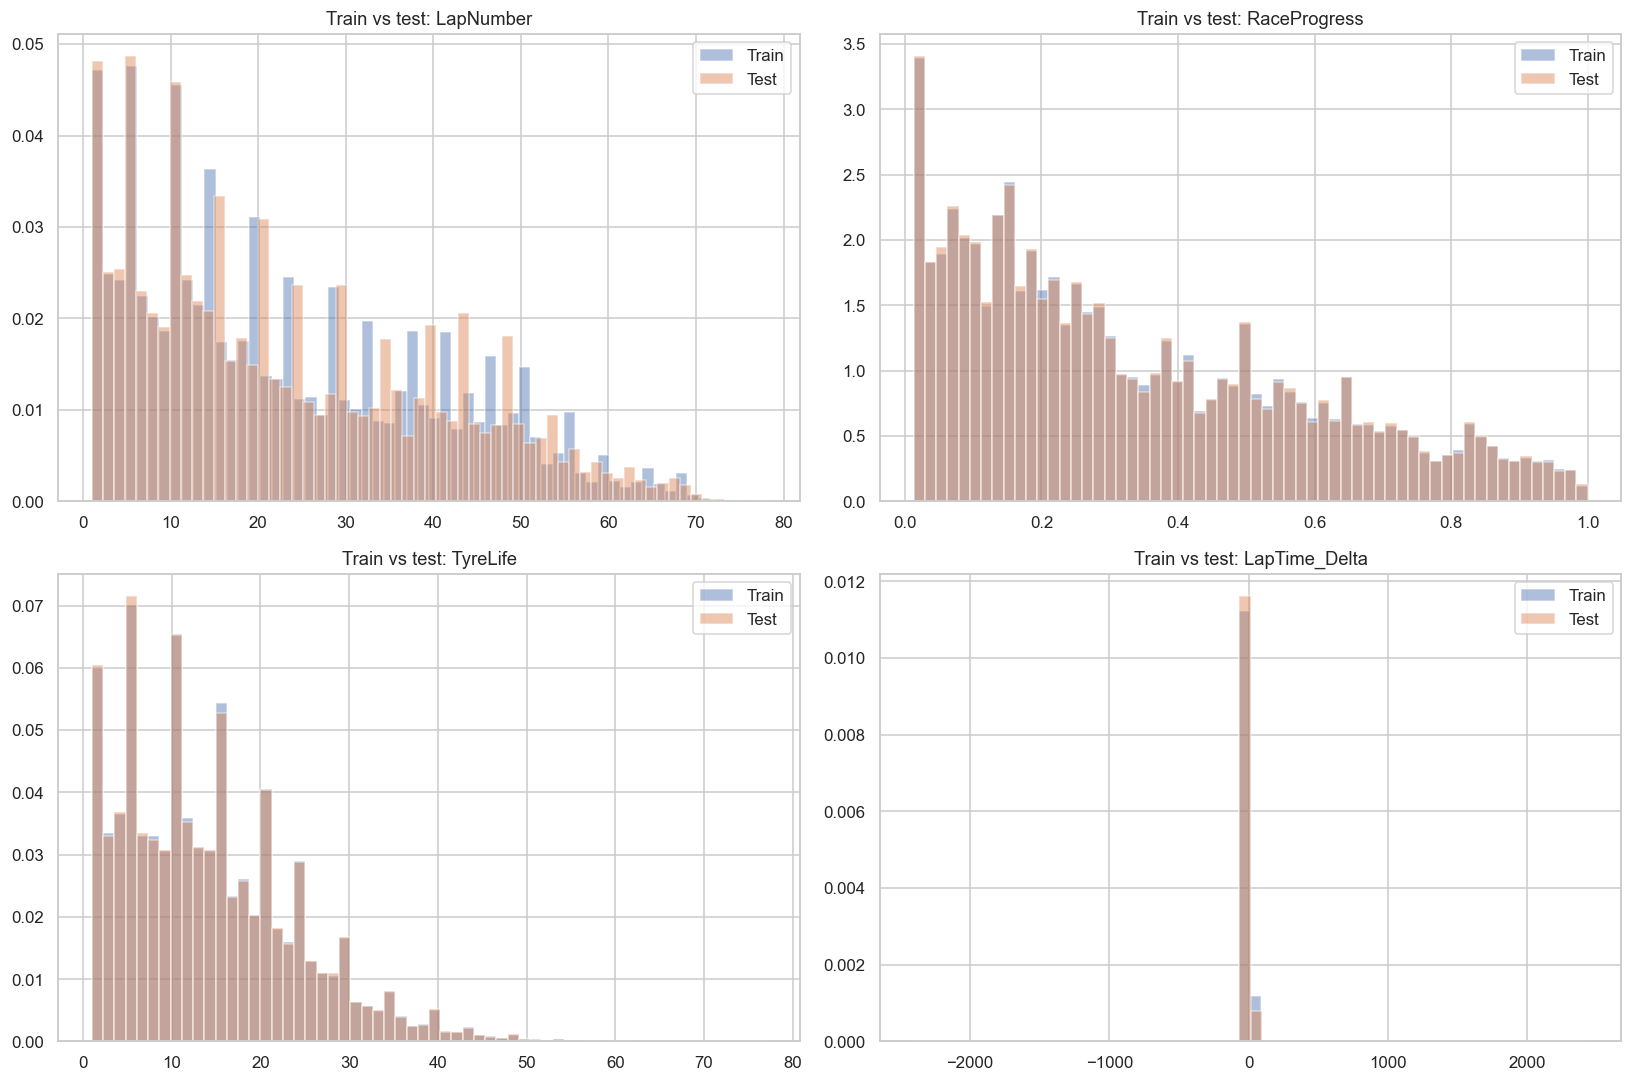

In [17]:
# Visualize the largest numerical shifts
largest_shift = shift_df.head(4)["Feature"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.flatten(), largest_shift):
    ax.hist(train[col].dropna(), bins=60, density=True, alpha=0.45, label="Train")
    ax.hist(test[col].dropna(), bins=60, density=True, alpha=0.45, label="Test")
    ax.set_title(f"Train vs test: {col}")
    ax.legend()
plt.tight_layout(); plt.show()

In [18]:
# Categorical distribution shift using total variation distance
cat_features = ["Driver", "Compound", "Race", "Year", "PitStop", "Stint", "Position"]
cat_shift = []
for col in cat_features:
    p = train[col].value_counts(normalize=True)
    q = test[col].value_counts(normalize=True)
    idx = p.index.union(q.index)
    tv = 0.5 * (p.reindex(idx, fill_value=0) - q.reindex(idx, fill_value=0)).abs().sum()
    cat_shift.append({"Feature": col, "Total variation": tv, "Train categories": train[col].nunique(), "Test categories": test[col].nunique()})
cat_shift_df = pd.DataFrame(cat_shift).sort_values("Total variation", ascending=False)
display(cat_shift_df)

,Feature,Total variation,Train categories,Test categories
0,Driver,0.025180,887,801
2,Race,0.005466,26,26
6,Position,0.003669,20,20
5,Stint,0.002739,8,8
1,Compound,0.002338,5,5
3,Year,0.002065,4,4
4,PitStop,0.000145,2,2


### Finding — check the highest-shift features before over-engineering
The KS statistic and categorical total-variation score identify where train/test differ most. Features with strong predictive power **and** large distribution shift deserve extra validation because they can hurt leaderboard generalization.

## 6. Correlation and association analysis

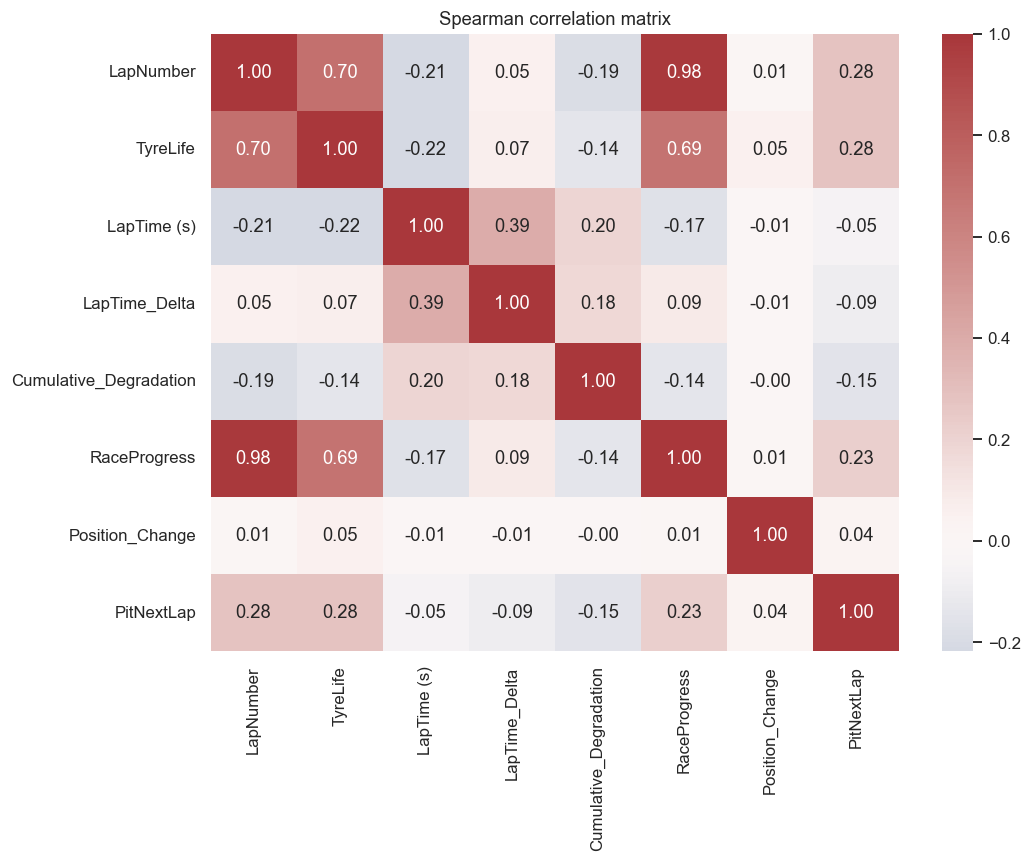

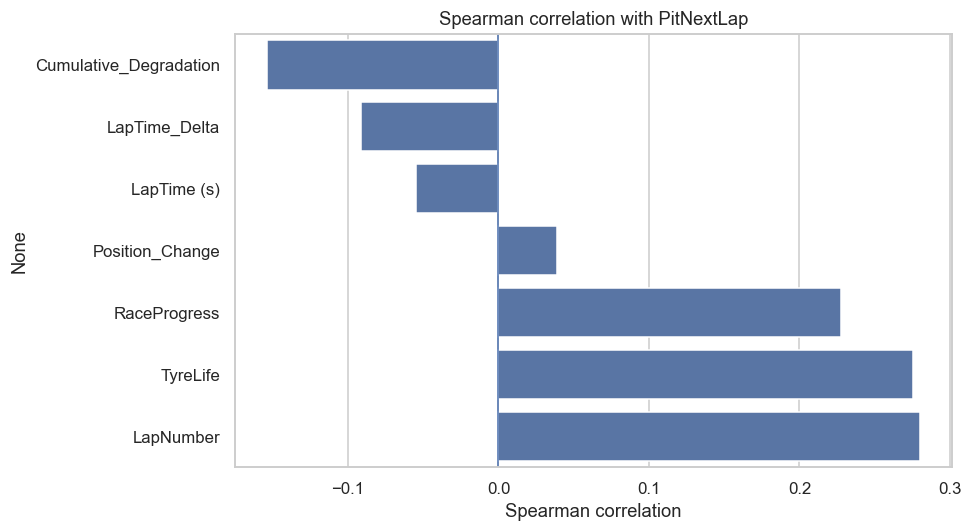

In [19]:
corr_cols = numeric_features + [TARGET]
spearman = train[corr_cols].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Spearman correlation matrix")
plt.tight_layout(); plt.show()

corr_target = spearman[TARGET].drop(TARGET).sort_values()
plt.figure(figsize=(9, 5))
sns.barplot(x=corr_target.values, y=corr_target.index, color="C0")
plt.axvline(0, linewidth=1)
plt.title("Spearman correlation with PitNextLap")
plt.xlabel("Spearman correlation")
plt.tight_layout(); plt.show()

## 7. Feature engineering from the EDA

The main idea is to expose relationships that are present implicitly in the raw data:

- **Estimated total laps** from current lap and race progress
- **Laps remaining** to represent the opportunity to pit
- **Tyre-life percentage** to normalize tyre age by race length
- **Absolute position change** to capture magnitude rather than direction only
- **Absolute lap-time delta** to represent performance change regardless of sign
- **Compound × stint** and **year × compound** interactions
- **Race × compound** context where useful to tree models

These are not target-derived, so they can be calculated identically for train and test.

In [20]:
def add_features(df):
    df = df.copy()

    progress = df["RaceProgress"].clip(lower=1e-4, upper=1.0)
    total_laps = (df["LapNumber"] / progress).replace([np.inf, -np.inf], np.nan)
    df["TotalLaps_est"] = total_laps
    df["LapsRemaining_est"] = (total_laps - df["LapNumber"]).clip(lower=0)
    df["TyreLifePct"] = df["TyreLife"] / total_laps.clip(lower=1)
    df["Position_Change_abs"] = df["Position_Change"].abs()
    df["LapTimeDelta_abs"] = df["LapTime_Delta"].abs()
    df["Degradation_abs"] = df["Cumulative_Degradation"].abs()
    df["Compound_Stint"] = df["Compound"].astype(str) + "_S" + df["Stint"].astype(str)
    df["Year_Compound"] = df["Year"].astype(str) + "_" + df["Compound"].astype(str)
    df["PitStop_Compound"] = df["PitStop"].astype(str) + "_" + df["Compound"].astype(str)
    return df

train_fe = add_features(train.drop(columns=[ID_COL]))
test_fe = add_features(test.drop(columns=[ID_COL]))

print("Original features:", train.shape[1] - 2)
print("Model features after engineering:", train_fe.shape[1] - 1)
display(train_fe.head())

Original features: 14
Model features after engineering: 23


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),...,PitNextLap,TotalLaps_est,LapsRemaining_est,TyreLifePct,Position_Change_abs,LapTimeDelta_abs,Degradation_abs,Compound_Stint,Year_Compound,PitStop_Compound
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,...,1.0,70.0,20.0,0.557143,5.0,7.564,21.019,HARD_S2,2022_HARD,0_HARD
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,...,0.0,78.0,51.0,0.089744,3.0,32.617,223.207,HARD_S2,2025_HARD,1_HARD
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,...,1.0,72.0,13.0,0.305556,3.0,7.540,100.529,HARD_S3,2022_HARD,0_HARD
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,...,0.0,26.0,24.0,0.076923,0.0,7.324,7.324,MEDIUM_S1,2023_MEDIUM,0_MEDIUM
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,...,0.0,72.0,46.0,0.083333,3.0,8.965,14.139,HARD_S3,2022_HARD,1_HARD


## 8. Model validation

A random stratified split gives a fast baseline. Because observations from the same race are related, we also provide a **race-grouped split** as a stricter diagnostic. The grouped score is often more conservative and is useful for detecting race memorization.

In [21]:
X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET].astype(int)

# LightGBM categorical columns
categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
for c in categorical_cols:
    X[c] = X[c].astype("category")

X_test = test_fe.copy()
for c in categorical_cols:
    X_test[c] = X_test[c].astype("category")
    # Align categories to train categories
    X_test[c] = X_test[c].cat.set_categories(X[c].cat.categories)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

model = LGBMClassifier(
    objective="binary",
    n_estimators=4000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.90,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    categorical_feature=categorical_cols,
    eval_set=[(X_valid, y_valid)],
    callbacks=[early_stopping(150, verbose=False), log_evaluation(100)],
)

valid_pred = model.predict_proba(X_valid)[:, 1]
print("Best iteration:", model.best_iteration_)
print("Validation ROC-AUC:", round(roc_auc_score(y_valid, valid_pred), 6))
print("Validation PR-AUC:", round(average_precision_score(y_valid, valid_pred), 6))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74274, number of negative: 298995
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3072
[LightGBM] [Info] Number of data points in the train set: 373269, number of used features: 23
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198983 -> initscore=-1.392666
[LightGBM] [Info] Start training from score -1.392666
[100]	valid_0's binary_logloss: 0.252279
[200]	valid_0's binary_logloss: 0.240581
[300]	valid_0's binary_logloss:

,Feature,Importance
0,Driver,19686
2,Race,4757
21,Year_Compound,1587
16,TyreLifePct,1584
12,RaceProgress,1472
20,Compound_Stint,1380
7,TyreLife,1056
18,LapTimeDelta_abs,1002
9,LapTime (s),929
10,LapTime_Delta,894


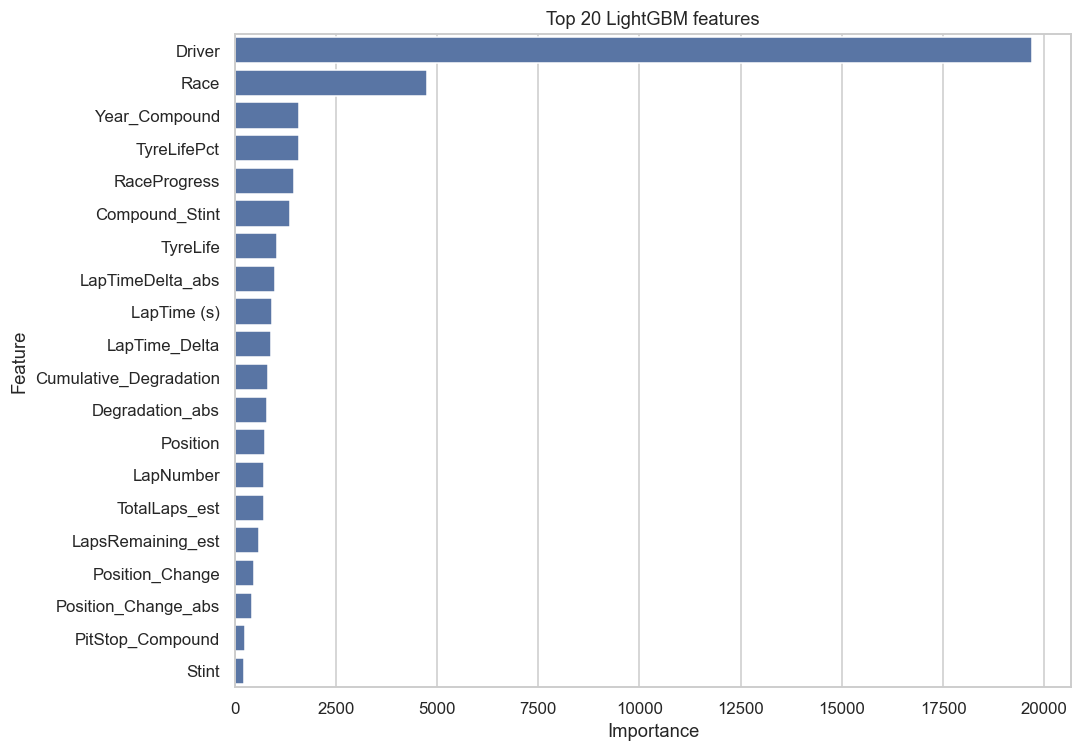

In [22]:
# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

display(importance)
plt.figure(figsize=(10, 7))
sns.barplot(data=importance, x="Importance", y="Feature", color="C0")
plt.title("Top 20 LightGBM features")
plt.tight_layout(); plt.show()

### Finding — let the model confirm the EDA
Use the feature-importance chart to check whether the engineered race-state and tyre-state variables are actually contributing. If an engineered feature has negligible importance, it can be removed in a later tuning pass.

## 9. Optional multi-seed ensemble

Averaging a few LightGBM models trained with different seeds can improve leaderboard stability. Start with one model for speed; set `N_ENSEMBLE_MODELS = 3` if runtime is acceptable.

In [23]:
N_ENSEMBLE_MODELS = 1
SEEDS = [42, 2026, 3407][:N_ENSEMBLE_MODELS]
best_iter = int(model.best_iteration_ or 800)

ensemble_preds = []
for seed in SEEDS:
    m = LGBMClassifier(
        objective="binary",
        n_estimators=best_iter,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=40,
        subsample=0.85,
        colsample_bytree=0.90,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
    )
    m.fit(X, y, categorical_feature=categorical_cols)
    ensemble_preds.append(m.predict_proba(X_test)[:, 1])

pred = np.mean(ensemble_preds, axis=0)
print("Prediction range:", float(pred.min()), "to", float(pred.max()))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 87381, number of negative: 351759
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3068
[LightGBM] [Info] Number of data points in the train set: 439140, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198982 -> initscore=-1.392668
[LightGBM] [Info] Start training from score -1.392668
Prediction range: 5.81935255103759e-05 to 0.9889355877322847


## 10. Create submission

In [ ]:
submission = sample_submission.copy()
submission[TARGET] = pred

assert len(submission) == len(test)
assert submission[ID_COL].equals(test[ID_COL])
assert submission[TARGET].between(0, 1).all()

OUTPUT_PATH = "best_quality_eda_enhanced.csv"
submission.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")
display(submission.head())

## Final takeaways

1. **Do not drop `Driver` automatically.** It is present across train/test and can carry useful strategy differences.
2. **Tyre state + race state are central signals.** Tyre life, race progress, lap number and lap-time/degradation behavior should be analyzed together.
3. **Train/test drift matters.** The shift tables should be checked before adding highly specific target encodings.
4. **Use ROC-AUC for model selection.** The target is imbalanced, so accuracy is not a useful primary metric.
5. **Feature engineering is inexpensive.** The engineered variables expose remaining race distance and normalized tyre age without using the target.
6. **Use grouped validation as a reality check.** Random validation can be optimistic when many rows come from the same race.
7. **Only train/test/sample_submission are used in this notebook.** External data has been deliberately removed so the result is reproducible from the three provided files.